# Step 3: Temporal Cross-Modal Disclosure Alpha Model

In [ ]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

if 'HF_TOKEN' not in os.environ:
    pass

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_PROC = 'data/processed'
os.makedirs('outputs', exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

TRAIN_END = pd.Timestamp('2022-12-31')
VAL_END   = pd.Timestamp('2023-06-30')

MKT_FEATURE_COLS = [
    'ret_1d_lag', 'ret_5d_lag', 'ret_20d_lag', 'ret_60d_lag',
    'mom_12m_1m', 'rvol_20d', 'rvol_60d', 'vol_zscore_20d',
]

## 1. Load Event Data

In [ ]:
events = pd.read_parquet(os.path.join(DATA_PROC, 'events_with_finbert.parquet'))
texts  = pd.read_parquet(os.path.join(DATA_PROC, 'events_text.parquet'))

n_before = len(events)
events = events.drop_duplicates(subset='accession').reset_index(drop=True)
texts  = texts.drop_duplicates(subset='accession').reset_index(drop=True)
if len(events) != n_before:
    print(f'[dedup] events: {n_before} -> {len(events)} rows')

events['event_date'] = pd.to_datetime(events['event_date'])
texts['event_date']  = pd.to_datetime(texts['event_date'])

events = events.merge(texts[['accession', 'text']], on='accession', how='left')
events = events.sort_values(['ticker', 'form', 'event_date']).reset_index(drop=True)

assert events['accession'].is_unique, \
    f'Accession not unique after merges: {len(events)} rows vs {events["accession"].nunique()} unique'

print(f'Events loaded: {len(events)}')
print(events[['ticker', 'form', 'event_date', 'exc_ret_5d']].head())

Events loaded: 17032
  ticker  form event_date  exc_ret_5d
0      A  10-K 2015-12-21    0.006197
1      A  10-K 2016-12-20   -0.000484
2      A  10-K 2017-12-21   -0.006239
3      A  10-K 2018-12-20    0.006956
4      A  10-K 2019-12-19    0.001757


## 2. FinBERT Chunk Embeddings (Hierarchical Text Encoder)

In [ ]:
EMB_CACHE = os.path.join(DATA_PROC, 'filing_embeddings.npy')
EMB_INDEX = os.path.join(DATA_PROC, 'filing_embeddings_index.parquet')

EMBED_DIM    = 768
CHUNK_TOKENS = 400
CHUNK_STRIDE = 200
MAX_CHUNKS   = 8
BATCH_SIZE   = 128

MAX_CHARS = MAX_CHUNKS * CHUNK_TOKENS * 7

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
tokenizer  = AutoTokenizer.from_pretrained('ProsusAI/finbert')
bert_model = AutoModel.from_pretrained('ProsusAI/finbert').to(DEVICE).eval()
print(f'Model loaded on {DEVICE}')

CLS_ID = tokenizer.cls_token_id
SEP_ID = tokenizer.sep_token_id


def tokenize_to_chunks(text: str):
    """Pre-truncate then tokenize. Returns list of 1-D token tensors (≤512 each)."""
    if not text or len(text.strip()) < 50:
        return []
    text = text[:MAX_CHARS]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        token_ids = tokenizer(
            text, return_tensors='pt',
            truncation=False, add_special_tokens=False
        )['input_ids'][0]

    chunks, start = [], 0
    while start < len(token_ids) and len(chunks) < MAX_CHUNKS:
        end   = min(start + CHUNK_TOKENS, len(token_ids))
        chunk = torch.cat([
            torch.tensor([CLS_ID]),
            token_ids[start:end],
            torch.tensor([SEP_ID]),
        ])[:512]
        chunks.append(chunk)
        start += CHUNK_STRIDE
    return chunks


@torch.no_grad()
def embed_all_filings_batched(texts: list, batch_size: int = BATCH_SIZE) -> np.ndarray:
    all_chunks, chunk_to_doc = [], []
    for doc_idx, text in enumerate(tqdm(texts, desc='Tokenizing', mininterval=2.0)):
        chunks = tokenize_to_chunks(text)
        if not chunks:
            chunks = [torch.tensor([CLS_ID, SEP_ID])]
        for c in chunks:
            all_chunks.append(c)
            chunk_to_doc.append(doc_idx)

    n_docs, n_chunks = len(texts), len(all_chunks)
    print(f'\nChunks: {n_chunks}  |  Filings: {n_docs}  |  '
          f'Avg {n_chunks/n_docs:.1f} chunks/filing  |  '
          f'Batches: {-(-n_chunks // batch_size)}')

    doc_emb_sums   = np.zeros((n_docs, EMBED_DIM), dtype=np.float64)
    doc_emb_counts = np.zeros(n_docs, dtype=np.int32)

    for batch_start in tqdm(range(0, n_chunks, batch_size), desc='Embedding (GPU batched)'):
        batch_chunks  = all_chunks[batch_start: batch_start + batch_size]
        batch_doc_ids = chunk_to_doc[batch_start: batch_start + batch_size]

        max_len   = max(c.shape[0] for c in batch_chunks)
        input_ids = torch.zeros(len(batch_chunks), max_len, dtype=torch.long)
        attn_mask = torch.zeros(len(batch_chunks), max_len, dtype=torch.long)
        for i, c in enumerate(batch_chunks):
            input_ids[i, :c.shape[0]] = c
            attn_mask[i, :c.shape[0]] = 1

        out      = bert_model(input_ids.to(DEVICE), attention_mask=attn_mask.to(DEVICE))
        cls_embs = out.last_hidden_state[:, 0, :].cpu().numpy()

        for i, doc_idx in enumerate(batch_doc_ids):
            doc_emb_sums[doc_idx]   += cls_embs[i]
            doc_emb_counts[doc_idx] += 1

    counts_safe = np.maximum(doc_emb_counts, 1)[:, None]
    return (doc_emb_sums / counts_safe).astype(np.float32)


def _load_and_validate_emb_cache():
    if not (os.path.exists(EMB_CACHE) and os.path.exists(EMB_INDEX)):
        return None, None
    arr = np.load(EMB_CACHE)
    idx = pd.read_parquet(EMB_INDEX)
    if not idx['accession'].is_unique:
        print(f'[cache] emb_index has {len(idx)-idx["accession"].nunique()} '
              f'duplicate accessions — ignoring cache, will recompute')
        return None, None
    if len(arr) != len(idx):
        print(f'[cache] size mismatch (arr={len(arr)}, idx={len(idx)}) — will recompute')
        return None, None
    return arr, idx


_cached_arr, _cached_idx = _load_and_validate_emb_cache()
if _cached_arr is not None:
    all_embeddings = _cached_arr
    emb_index      = _cached_idx
    print(f'Loaded cached embeddings: {all_embeddings.shape}')
else:
    texts_list     = events['text'].fillna('').tolist()
    all_embeddings = embed_all_filings_batched(texts_list, batch_size=BATCH_SIZE)
    np.save(EMB_CACHE, all_embeddings)
    emb_index = events[['accession']].copy()
    emb_index['emb_row'] = np.arange(len(events))
    emb_index.to_parquet(EMB_INDEX, index=False)
    print(f'Saved embeddings: {all_embeddings.shape}')

events = events.merge(emb_index, on='accession', how='left')

assert events['accession'].is_unique, \
    f'Row inflation after emb_index merge: {len(events)} rows vs {events["accession"].nunique()} unique accessions'

n_missing = events['emb_row'].isna().sum()
if n_missing > 0:
    print(f'[warn] {n_missing} events have no matching embedding — they will drop out downstream')

print(f'Embedding shape: {all_embeddings.shape}  |  Events: {len(events)}  |  Device: {DEVICE}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded on cuda
Loaded cached embeddings: (17032, 768)
Embedding shape: (17032, 768)  |  Events: 17032  |  Device: cuda


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as EmbScaler

PCA_DIM  = 64
PCA_CACHE = os.path.join(DATA_PROC, 'filing_embeddings_pca.npy')

train_mask_pca = events['event_date'] <= TRAIN_END

if os.path.exists(PCA_CACHE):
    all_embeddings_pca = np.load(PCA_CACHE)
    print(f'Loaded cached PCA embeddings: {all_embeddings_pca.shape}')
else:
    print(f'Fitting PCA (dim {EMBED_DIM} → {PCA_DIM}) on training events only...')
    train_emb_rows = events.loc[train_mask_pca, 'emb_row'].dropna().astype(int).values
    X_train_emb = all_embeddings[train_emb_rows]

    pca = PCA(n_components=PCA_DIM, random_state=42)
    pca.fit(X_train_emb)
    explained = pca.explained_variance_ratio_.sum()
    print(f'  Variance explained by {PCA_DIM} components: {explained:.1%}')

    all_embeddings_pca = pca.transform(all_embeddings).astype(np.float32)
    np.save(PCA_CACHE, all_embeddings_pca)

    import joblib
    joblib.dump(pca, os.path.join(DATA_PROC, 'pca_model.pkl'))
    print(f'Saved PCA embeddings: {all_embeddings_pca.shape}')

EMBED_DIM = PCA_DIM
print(f'EMBED_DIM updated to {EMBED_DIM} (PCA-reduced)')

Loaded cached PCA embeddings: (17032, 64)
EMBED_DIM updated to 64 (PCA-reduced)


## 3. Temporal Change Module

In [ ]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8
    return float(np.dot(a, b) / denom)

prior_emb_rows = []
cosine_sims    = []
days_since     = []

events_sorted = events.sort_values(['ticker', 'form', 'event_date']).reset_index(drop=True)

from collections import defaultdict
history = defaultdict(list)

for _, row in events_sorted.iterrows():
    key = (row['ticker'], row['form'])
    prior_list = history[key]

    if len(prior_list) == 0:
        prior_emb_rows.append(-1)
        cosine_sims.append(0.0)
        days_since.append(365.0)
    else:
        prior_date, prior_row_idx = prior_list[-1]
        cur_emb   = all_embeddings[int(row['emb_row'])]
        prior_emb = all_embeddings[prior_row_idx]
        prior_emb_rows.append(prior_row_idx)
        cosine_sims.append(cosine_sim(cur_emb, prior_emb))
        days_since.append((row['event_date'] - prior_date).days)

    history[key].append((row['event_date'], int(row['emb_row'])))

events_sorted['prior_emb_row'] = prior_emb_rows
events_sorted['cosine_sim']    = cosine_sims
events_sorted['days_since_prior'] = days_since

events = events_sorted.reset_index(drop=True)

print('Prior filing coverage:')
print(f'  Has prior: {(events.prior_emb_row >= 0).sum()} / {len(events)}')
print(f'  Cosine sim stats: mean={events.cosine_sim.mean():.3f}  std={events.cosine_sim.std():.3f}')

Prior filing coverage:
  Has prior: 16115 / 17032
  Cosine sim stats: mean=0.940  std=0.225


In [ ]:
class FilingDataset(Dataset):
    def __init__(self, df: pd.DataFrame, embeddings: np.ndarray,
                 label_col: str, use_rank_target: bool = False):
        self.df         = df.reset_index(drop=True)
        self.embeddings = embeddings
        self.label_col  = label_col
        self.use_rank_target = use_rank_target

        if use_rank_target:
            d = self.df[['event_date', label_col]].copy()
            d['_month'] = d['event_date'].dt.to_period('M')
            d['_rank'] = d.groupby('_month')[label_col].rank(pct=True) - 0.5
            self._rank_target = d['_rank'].values.astype(np.float32)
        else:
            self._rank_target = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        cur_emb = torch.tensor(self.embeddings[int(row['emb_row'])], dtype=torch.float32)

        if row['prior_emb_row'] >= 0:
            prior_emb = torch.tensor(self.embeddings[int(row['prior_emb_row'])], dtype=torch.float32)
        else:
            prior_emb = torch.zeros(self.embeddings.shape[1], dtype=torch.float32)

        emb_diff   = cur_emb - prior_emb
        cosine     = torch.tensor([row['cosine_sim']], dtype=torch.float32)
        days_since = torch.tensor([min(row['days_since_prior'], 730) / 365.0], dtype=torch.float32)

        mkt_feats = torch.tensor(
            row[MKT_FEATURE_COLS].values.astype(np.float32), dtype=torch.float32
        )

        if self.use_rank_target:
            label = torch.tensor(float(self._rank_target[idx]), dtype=torch.float32)
        else:
            label = torch.tensor(row[self.label_col], dtype=torch.float32)

        return {
            'cur_emb':   cur_emb,
            'emb_diff':  emb_diff,
            'cosine':    cosine,
            'days_since':days_since,
            'mkt_feats': mkt_feats,
            'label':     label,
        }

needed_cols = MKT_FEATURE_COLS + ['exc_ret_5d', 'exc_ret_20d', 'emb_row', 'prior_emb_row',
                                    'cosine_sim', 'days_since_prior', 'form']
events_clean = events.dropna(subset=needed_cols).reset_index(drop=True)
print(f'Clean events: {len(events_clean)}')
print(f'  Form breakdown: {events_clean["form"].value_counts().to_dict()}')

TRAIN_END = pd.Timestamp('2022-12-31')
VAL_END   = pd.Timestamp('2023-12-31')

train_df = events_clean[events_clean['event_date'] <= TRAIN_END].reset_index(drop=True)
val_df   = events_clean[(events_clean['event_date'] > TRAIN_END) &
                         (events_clean['event_date'] <= VAL_END)].reset_index(drop=True)
test_df  = events_clean[events_clean['event_date'] > VAL_END].reset_index(drop=True)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print(f'  Train range: {train_df["event_date"].min().date()} to {train_df["event_date"].max().date()}')
print(f'  Val   range: {val_df["event_date"].min().date()} to {val_df["event_date"].max().date()}')
print(f'  Test  range: {test_df["event_date"].min().date()} to {test_df["event_date"].max().date()}')

Clean events: 15284
  Form breakdown: {'10-Q': 11313, '10-K': 3971}
Train: 12545  Val: 1821  Test: 918
  Train range: 2016-01-06 to 2022-12-29
  Val   range: 2023-01-04 to 2023-12-21
  Test  range: 2024-01-03 to 2024-06-28


In [ ]:
class TCMDAModel(nn.Module):
    def __init__(self, embed_dim=None, mkt_dim=8, hidden=48, proj=24, dropout=0.35):
        super().__init__()
        if embed_dim is None:
            embed_dim = EMBED_DIM

        self.text_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj),
        )

        self.change_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj),
        )

        self.mkt_proj = nn.Sequential(
            nn.Linear(mkt_dim, proj),
            nn.LayerNorm(proj),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(proj, proj),
        )

        fused_dim = proj + proj + proj + 2
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj),
            nn.GELU(),
            nn.Linear(proj, 1),
        )

    def forward(self, cur_emb, emb_diff, cosine, days_since, mkt_feats):
        t = self.text_proj(cur_emb)
        c = self.change_proj(emb_diff)
        m = self.mkt_proj(mkt_feats)
        scalar = torch.cat([cosine, days_since], dim=-1)
        fused  = torch.cat([t, c, m, scalar], dim=-1)
        return self.fusion(fused).squeeze(-1)


model = TCMDAModel().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model input dim: {EMBED_DIM}  (PCA-reduced from 768)')
print(f'Model parameters: {total_params:,}')
print(model)

Model input dim: 64  (PCA-reduced from 768)
Model parameters: 14,545
TCMDAModel(
  (text_proj): Sequential(
    (0): Linear(in_features=64, out_features=48, bias=True)
    (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=48, out_features=24, bias=True)
  )
  (change_proj): Sequential(
    (0): Linear(in_features=64, out_features=48, bias=True)
    (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=48, out_features=24, bias=True)
  )
  (mkt_proj): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): LayerNorm((24,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=24, out_features=24, bias=True)
  )
  (fusion): Sequential(
 

In [ ]:
def pearson_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred_c   = pred - pred.mean()
    target_c = target - target.mean()
    num = (pred_c * target_c).sum()
    den = torch.sqrt((pred_c ** 2).sum() * (target_c ** 2).sum() + 1e-12)
    return -(num / den)


def _forward_batch(net, batch):
    return net(
        batch['cur_emb'].to(DEVICE),
        batch['emb_diff'].to(DEVICE),
        batch['cosine'].to(DEVICE),
        batch['days_since'].to(DEVICE),
        batch['mkt_feats'].to(DEVICE),
    )


def train_model(label_col: str, epochs: int = 80, batch_size: int = 128,
                lr: float = 3e-4, patience: int = 15,
                mse_weight: float = 1.0, corr_weight: float = 0.5,
                use_rank_target: bool = True):
    train_ds = FilingDataset(train_df, all_embeddings_pca, label_col,
                              use_rank_target=use_rank_target)
    val_ds   = FilingDataset(val_df,   all_embeddings_pca, label_col,
                              use_rank_target=use_rank_target)

    val_raw_returns = val_df[label_col].values

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)

    net = TCMDAModel().to(DEVICE)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=3e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse_fn = nn.MSELoss()

    best_ic, best_weights, no_improve = -np.inf, None, 0
    history = {'train_loss': [], 'val_ic': []}

    target_label = 'rank-within-month' if use_rank_target else label_col
    print(f'  training target: {target_label}')

    for epoch in range(epochs):
        net.train()
        running_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            preds  = _forward_batch(net, batch)
            labels = batch['label'].to(DEVICE)
            loss   = mse_weight * mse_fn(preds, labels) + \
                     corr_weight * pearson_loss(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * len(labels)
        scheduler.step()
        avg_loss = running_loss / (len(train_loader) * batch_size)

        net.eval()
        val_preds = []
        with torch.no_grad():
            for batch in val_loader:
                p = _forward_batch(net, batch)
                val_preds.extend(p.cpu().numpy())
        val_preds = np.array(val_preds)

        val_ic = spearmanr(val_preds, val_raw_returns)[0]
        if np.isnan(val_ic):
            val_ic = 0.0
        history['train_loss'].append(avg_loss)
        history['val_ic'].append(val_ic)

        if val_ic > best_ic:
            best_ic      = val_ic
            best_weights = {k: v.cpu().clone() for k, v in net.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}  loss={avg_loss:.5f}  val_IC={val_ic:+.4f}  best={best_ic:+.4f}')
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    net.load_state_dict(best_weights)
    print(f'Best val IC: {best_ic:+.4f}')
    return net, history


print('Training for 5-day excess return (rank-target)...')
model_5d, hist_5d = train_model('exc_ret_5d', use_rank_target=True)
print('\nTraining for 20-day excess return (rank-target)...')
model_20d, hist_20d = train_model('exc_ret_20d', use_rank_target=True)

Training for 5-day excess return (rank-target)...
  training target: rank-within-month
Epoch  10  loss=0.05022  val_IC=-0.0288  best=+0.0166
Early stopping at epoch 16
Best val IC: +0.0166

Training for 20-day excess return (rank-target)...
  training target: rank-within-month
Epoch  10  loss=0.05057  val_IC=+0.0279  best=+0.0586
Early stopping at epoch 19
Best val IC: +0.0586


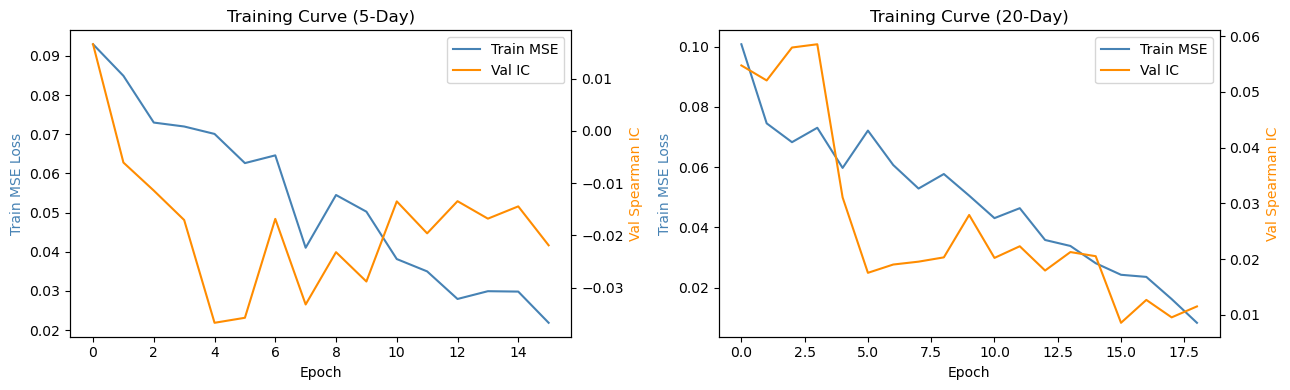

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (hist, label) in zip(axes, [(hist_5d, '5-Day'), (hist_20d, '20-Day')]):
    ax2 = ax.twinx()
    ax.plot(hist['train_loss'], color='steelblue', label='Train MSE')
    ax2.plot(hist['val_ic'],    color='darkorange', label='Val IC')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train MSE Loss', color='steelblue')
    ax2.set_ylabel('Val Spearman IC', color='darkorange')
    ax.set_title(f'Training Curve ({label})')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/03_training_curves.png', dpi=150)
plt.show()

In [ ]:
def predict(net: nn.Module, df: pd.DataFrame, label_col: str,
            batch_size: int = 128) -> np.ndarray:
    ds = FilingDataset(df, all_embeddings_pca, label_col)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    net.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            p = _forward_batch(net, batch)
            preds.extend(p.cpu().numpy())
    return np.array(preds)


test_pred_5d  = predict(model_5d,  test_df, 'exc_ret_5d')
test_pred_20d = predict(model_20d, test_df, 'exc_ret_20d')

for preds, label_col, horizon in [
    (test_pred_5d,  'exc_ret_5d',  '5-day'),
    (test_pred_20d, 'exc_ret_20d', '20-day'),
]:
    actual = test_df[label_col].values
    ic, pval = spearmanr(preds, actual)
    print(f'Proposed model ({horizon}) — OOS IC (pooled): {ic:+.4f}  p={pval:.4f}')

print('\nOOS IC by form type (the finding that drives our 10-Q-only backtest):')
for form in ['10-Q', '10-K']:
    mask = test_df['form'] == form
    n = mask.sum()
    if n < 20:
        continue
    ic5,  p5  = spearmanr(test_pred_5d[mask],  test_df.loc[mask, 'exc_ret_5d'])
    ic20, p20 = spearmanr(test_pred_20d[mask], test_df.loc[mask, 'exc_ret_20d'])
    print(f'  {form}  n={n:4d}:  IC_5d={ic5:+.4f} (p={p5:.3f})  IC_20d={ic20:+.4f} (p={p20:.3f})')

Proposed model (5-day) — OOS IC (pooled): +0.0195  p=0.5557
Proposed model (20-day) — OOS IC (pooled): +0.0330  p=0.3174

OOS IC by form type (the finding that drives our 10-Q-only backtest):
  10-Q  n= 533:  IC_5d=-0.0347 (p=0.424)  IC_20d=+0.0872 (p=0.044)
  10-K  n= 385:  IC_5d=+0.0674 (p=0.187)  IC_20d=-0.0443 (p=0.386)


## 8. Compare Proposed Model vs Baselines

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ALL_FEATURES = ['sentiment', 'p_pos', 'p_neg'] + MKT_FEATURE_COLS

def compute_b2_predictions(train_df, test_df, label_col):
    sub_train = train_df[ALL_FEATURES + [label_col]].dropna()
    sub_test  = test_df[ALL_FEATURES + [label_col]].dropna()
    scaler = StandardScaler()
    X_train = scaler.fit_transform(sub_train[ALL_FEATURES].values)
    X_test  = scaler.transform(sub_test[ALL_FEATURES].values)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, sub_train[label_col].values)
    return ridge.predict(X_test), sub_test[label_col].values


results = {}
for label_col, horizon, pred_proposed in [
    ('exc_ret_5d',  '5-day',  test_pred_5d),
    ('exc_ret_20d', '20-day', test_pred_20d),
]:
    actual = test_df[label_col].values

    b1_signal = test_df['sentiment'].values
    ic_b1, _  = spearmanr(b1_signal, actual)

    b2_preds, b2_actual = compute_b2_predictions(train_df, test_df, label_col)
    ic_b2, _ = spearmanr(b2_preds, b2_actual)

    ic_prop, _ = spearmanr(pred_proposed, actual)

    results[horizon] = {'Baseline 1 (FinBERT)': ic_b1,
                        'Baseline 2 (Ridge+Mkt)': ic_b2,
                        'Proposed (TCMDA)': ic_prop}
    print(f'\n{horizon} OOS Spearman IC:')
    for name, ic in results[horizon].items():
        print(f'  {name:<30}: {ic:.4f}')


5-day OOS Spearman IC:
  Baseline 1 (FinBERT)          : -0.0429
  Baseline 2 (Ridge+Mkt)        : -0.0571
  Proposed (TCMDA)              : 0.0195

20-day OOS Spearman IC:
  Baseline 1 (FinBERT)          : -0.0241
  Baseline 2 (Ridge+Mkt)        : 0.0035
  Proposed (TCMDA)              : 0.0330


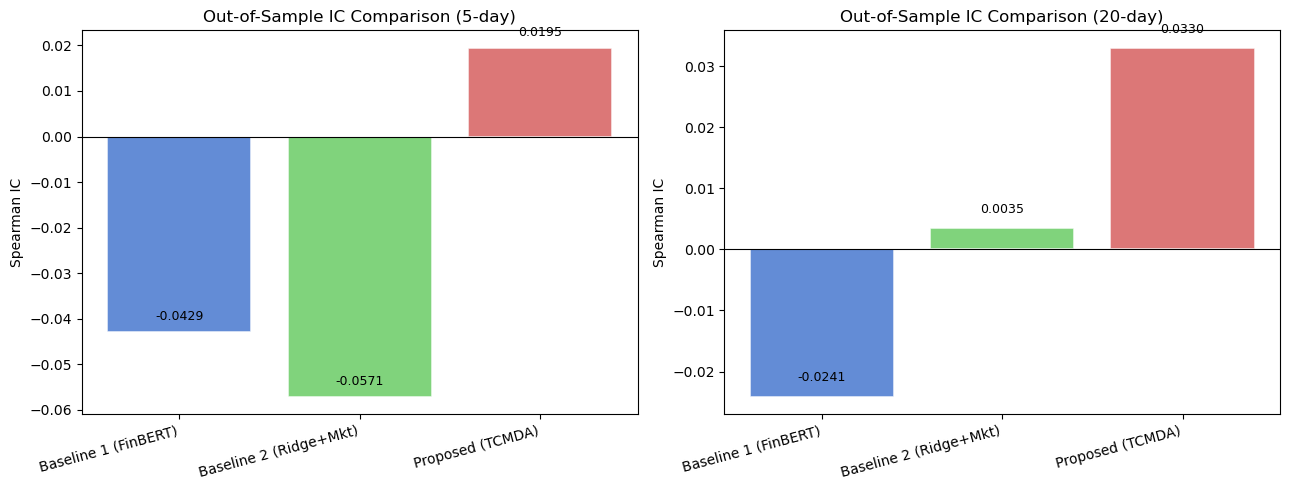

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, horizon in zip(axes, ['5-day', '20-day']):
    names = list(results[horizon].keys())
    ics   = list(results[horizon].values())
    bars  = ax.bar(names, ics, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Out-of-Sample IC Comparison ({horizon})')
    ax.set_ylabel('Spearman IC')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, ic in zip(bars, ics):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{ic:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_ic_comparison.png', dpi=150)
plt.show()

## 9. Save Model Predictions for Portfolio Construction

In [ ]:
torch.save(model_5d.state_dict(),  'data/processed/tcmda_5d.pt')
torch.save(model_20d.state_dict(), 'data/processed/tcmda_20d.pt')

signal_df = test_df[['ticker', 'event_date', 'form',
                      'exc_ret_5d', 'exc_ret_20d', 'sentiment']].copy()
signal_df['pred_5d_b2'],  _ = compute_b2_predictions(train_df, test_df, 'exc_ret_5d')
signal_df['pred_20d_b2'], _ = compute_b2_predictions(train_df, test_df, 'exc_ret_20d')
signal_df['pred_5d_tcmda']  = test_pred_5d
signal_df['pred_20d_tcmda'] = test_pred_20d

signal_df.to_parquet(os.path.join(DATA_PROC, 'test_signals.parquet'), index=False)
print('Saved: data/processed/test_signals.parquet')
print(signal_df.head())
print('\nStep 3 complete. Proceed to 04_portfolio_construction.ipynb')

Saved: data/processed/test_signals.parquet
  ticker event_date  form  exc_ret_5d  exc_ret_20d  sentiment  pred_5d_b2  \
0      A 2024-03-05  10-Q    0.007407    -0.028947  -0.037409    0.001615   
1      A 2024-06-03  10-Q    0.011528    -0.041942  -0.051190   -0.004176   
2   AAPL 2024-02-02  10-Q    0.010106    -0.098615  -0.122390   -0.003071   
3   AAPL 2024-05-03  10-Q   -0.021518     0.044066  -0.073749   -0.001965   
4   ABBV 2024-02-20  10-K    0.002631    -0.017901   0.052601    0.000417   

   pred_20d_b2  pred_5d_tcmda  pred_20d_tcmda  
0     0.002820      -0.019861        0.070263  
1    -0.003776       0.005251        0.044903  
2    -0.005680      -0.007517        0.042964  
3     0.000039      -0.019788        0.031679  
4    -0.005168      -0.055305        0.020755  

Step 3 complete. Proceed to 04_portfolio_construction.ipynb
